In [2]:
!pip install transformers==4.57.6
!pip install peft==0.7.1
!pip install pandas ipywidgets matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 60.1 MB/s eta 0:00:00
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
  Attempting uninstall: transformers
    Found existing installation: transformers 4.57.6
    Uninstalling transformers-4.57.6:
      Successfully uninstalled transformers-4.57.6
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.3/168.3 kB 9.8 MB/s eta 0:00:00
  Attempting uninstall: peft
    Found existing installation: peft 0.18.1
    Uninstalling peft-0.18.1:
      Successfully uninstalled peft-0.18.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 37.9 MB/s eta 0:00:00


In [3]:
# import libs
import torch, pandas as pd, numpy as np, re, torch.nn as nn, wandb
from datetime import datetime
from tqdm.auto import tqdm
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

In [4]:
df = pd.read_csv("drive/MyDrive/cases.csv")

df = df.sample(frac=1, random_state=42).reset_index(drop=True)
df.head(3) # civil = 0, criminal = 1, (legal_fees = 2)

,text,category,label
0,These are consolidated petitions for review on...,CIVIL,0
1,"In this Petition for Review onCertiorari, unde...",CIVIL,0
2,"Petitioners, spouses Divinia Publico (Divinia)...",CIVIL,0


In [5]:
# data cleaning/preprocessing
tqdm.pandas()

# func
def clean_legal_text(text, label=None):
    """
    Comprehensive legal text cleaning function.
    For legal_fees class, we keep numbers intact.
    """
    if not isinstance(text, str):
        return ""

    # 1. Handle line breaks and tabs
    text = text.replace('\n', ' ').replace('\r', ' ').replace('\t', ' ')

    # 2. Remove dates
    date_patterns = [
        r'\b\d{1,2}[-/]\d{1,2}[-/]\d{2,4}\b',  # DD-MM-YYYY
        r'\b\d{4}[-/]\d{1,2}[-/]\d{1,2}\b',    # YYYY-MM-DD
        r'\b(?:Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)[a-z]* \d{1,2},? \d{4}\b',
    ]
    for pattern in date_patterns:
        text = re.sub(pattern, '[DATE]', text, flags=re.IGNORECASE)

    # 3. Preserve legal punctuation but remove excessive special chars
    text = re.sub(r'[^\w\s.,;:?!()\-\[\]{}"\'§¶@#$%&*+=<>]', ' ', text)

    # 4. Normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # 5. Remove numbers for non-legal_fees
    if label != "legal_fees":
        text = ' '.join(re.findall(r"\d*[a-zA-Z][\w]*", text))

    return text


# call func
if 'text' in df.columns:
    df['cleaned_text'] = df.apply(lambda row: clean_legal_text(row['text'], row['label']), axis=1)

    # Save result
    df.to_csv("cases_cleaned.csv", index=False)
    print("Cleaning complete! Saved to cases_cleaned.csv")

    # Show samples
    for i in range(2):
        print(f"\nSample {i}:")
        print(df['cleaned_text'].iloc[i][:300])

df.head(3)

Cleaning complete! Saved to cases_cleaned.csv

Sample 0:
These are consolidated petitions for review oncertiorari praying for the reversal and or modification of the Decision dated DATE and Resolution dated DATE of the Court of Appeals CA in the case entitled Archimedes B Bernal v National Labor Relations Commission McConnell Dowell Phils Inc John Hearst 

Sample 1:
In this Petition for Review onCertiorari under Rule of the Revised Rules of Court petitioner San Roque Power Corporation assails the Decision of the Court of Tax Appeals CTA En Bancdated September in CTA EB No affirming the Decision dated March of the CTA Second Division in CTA Case No which dismiss


,text,category,label,cleaned_text
0,These are consolidated petitions for review on...,CIVIL,0,These are consolidated petitions for review on...
1,"In this Petition for Review onCertiorari, unde...",CIVIL,0,In this Petition for Review onCertiorari under...
2,"Petitioners, spouses Divinia Publico (Divinia)...",CIVIL,0,Petitioners spouses Divinia Publico Divinia an...


In [6]:
# stratified train-test split or stratified sampling (makes train and test split identical)

cleaned_df = pd.read_csv("cases_cleaned.csv")

train_df, test_df = train_test_split(
    cleaned_df,
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

print(f"\nTrain:")
print(train_df["label"].value_counts(normalize=True))
print(f"\nTest:")
print(test_df["label"].value_counts(normalize=True))


Train:
label
0    0.860208
1    0.091949
2    0.047843
Name: proportion, dtype: float64

Test:
label
0    0.860389
1    0.091779
2    0.047833
Name: proportion, dtype: float64


In [7]:
# encode labels

label_encoder = LabelEncoder()
all_labels = pd.concat([train_df['label'], test_df['label']])
label_encoder.fit(all_labels)

train_df["label_encoded"] = label_encoder.transform(train_df["label"])
test_df["label_encoded"] = label_encoder.transform(test_df["label"])

label_encoder.classes_

array([0, 1, 2])

In [8]:
# convert to huggingface dataset

train_dataset = Dataset.from_pandas(train_df)
eval_dataset = Dataset.from_pandas(test_df)

In [9]:
# load lb tokenizer

tokenizer = AutoTokenizer.from_pretrained(
    "nlpaueb/legal-bert-base-uncased"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [10]:
# tokenize

def tokenize_function(examples):
    return tokenizer(
        examples["cleaned_text"],
        truncation=True,
        padding="max_length",
        max_length=512
    )

train_tokenized = train_dataset.map(tokenize_function, batched=True)
eval_tokenized = eval_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/13377 [00:00<?, ? examples/s]

Map:   0%|          | 0/3345 [00:00<?, ? examples/s]

In [11]:
# load legalbert

model = AutoModelForSequenceClassification.from_pretrained(
    "nlpaueb/legal-bert-base-uncased",
    num_labels=3 # 2 for Bi-Classification, 3 otherwise (with legal fees)
)

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at nlpaueb/legal-bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [12]:
# training config

training_args = TrainingArguments(
    output_dir="./legalbert_model",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3, # change from 3-5 / if overfitting: 1-2
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=10,
    save_strategy="no",
    fp16=True
)

In [13]:
# metrics

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    accuracy = accuracy_score(labels, preds)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="macro",   # for imbalanced data
        zero_division=0
    )

    return {
        "accuracy": accuracy,
        "precision_macro": precision,
        "recall_macro": recall,
        "f1_macro": f1,
    }

In [14]:
weights = compute_class_weight(
    class_weight = 'balanced',
    classes=np.unique(train_df["label_encoded"]),
    y=train_df["label_encoded"]
)

# Convert to a Tensor and send to GPU/CPU
device = "cuda" if torch.cuda.is_available() else "cpu"
class_weights = torch.tensor(weights, dtype=torch.float).to(device)

for cls, w in zip(np.unique(train_df["label_encoded"]), weights):
    label_name = ["civil", "criminal", "legal_fees"][cls]
    print(f"Weight for {label_name} ({cls}): {w}")

Weight for civil (0): 0.38750325888589554
Weight for criminal (1): 3.62520325203252
Weight for legal_fees (2): 6.9671875


In [15]:
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        # Get predictions from Legal-BERT
        outputs = model(**inputs)
        logits = outputs.get("logits")

        # 'class_weights'
        loss_fct = nn.CrossEntropyLoss(weight=class_weights)

        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

In [16]:
# train

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=eval_tokenized,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

trainer.train()

wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.
/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Find your API key here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: peaksenut (peaksenut-ai) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: WARNING The get_url method is deprecated and will be removed in a future release. Please use `run.url` instead.


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,0.001500,0.053257,0.996413,0.998616,0.986971,0.992662
2,0.280100,0.048345,0.996413,0.995638,0.989881,0.992727


TrainOutput(global_step=3346, training_loss=0.0911007518780563, metrics={'train_runtime': 878.6198, 'train_samples_per_second': 30.45, 'train_steps_per_second': 3.808, 'total_flos': 7039336377894912.0, 'train_loss': 0.0911007518780563, 'epoch': 2.0})

In [17]:
# 1. Run prediction on your evaluation set
output = trainer.predict(eval_tokenized)

# 2. Extract the ground truth labels
labels = output.label_ids

# 3. Extract the predictions (and take the argmax)
import numpy as np
preds = np.argmax(output.predictions, axis=-1)

# 4. Now your classification report will work!
from sklearn.metrics import classification_report

target_names=["civil", "criminal", "legal_fees"]

print(classification_report(labels, preds, target_names=target_names, digits=4))

              precision    recall  f1-score   support

       civil     0.9969    0.9990    0.9979      2878
    criminal     0.9900    0.9707    0.9803       307
  legal_fees     1.0000    1.0000    1.0000       160

    accuracy                         0.9964      3345
   macro avg     0.9956    0.9899    0.9927      3345
weighted avg     0.9964    0.9964    0.9964      3345



<Figure size 600x600 with 0 Axes>

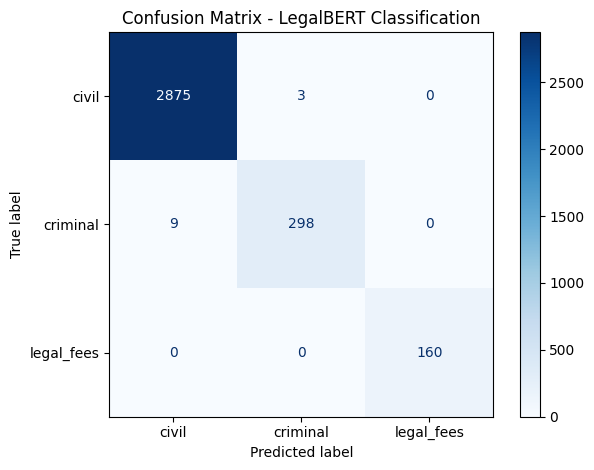

In [18]:
# confusion matrix

cm = confusion_matrix(labels, preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=target_names
)

plt.figure(figsize=(6, 6))
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - LegalBERT Classification")
plt.tight_layout()

plt.savefig("confusion_matrix.png", dpi=300)
plt.show()

In [19]:
classifier = pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer
)

In [20]:
# Generate timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")  # Format: 20240124_153045
model_path = f"drive/MyDrive/models/{timestamp}/legalbert_model_{timestamp}"

# Save
trainer.save_model(model_path)
tokenizer.save_pretrained(model_path)
print(f"Model saved to: {model_path}")

Model saved to: models/20260125_145604/legalbert_model_20260125_145604
